# 03 — DFT vs FFT, spectral leakage, and the Wiener–Khinchin theorem

Illustrates §5 and §6 of [`../FFT.md`](../FFT.md). Three demonstrations:

1. **Empirical scaling** of a hand-rolled DFT vs `numpy.fft.fft`, confirming the $O(N^2)$ → $O(N \log N)$ improvement (Cooley & Tukey, 1965).
2. **Spectral leakage** when an analysed sinusoid does not fit an integer number of periods in the record — the source of the windowing convention.
3. **Wiener–Khinchin** verification: the FFT of the autocorrelation of a stationary process equals (up to scaling) the periodogram, and Welch averaging (Welch, 1967) reduces estimator variance.

References: Cooley & Tukey (1965); Welch (1967); Heideman, Johnson, & Burrus (1984); Oppenheim & Schafer (2010); Bracewell (2000).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

rng = np.random.default_rng(2026)

## 1. DFT (O(N²)) vs FFT (O(N log N))

We implement the direct-sum DFT explicitly and benchmark it against `numpy.fft.fft` for $N \in \{32, 64, 128, \dots, 4096\}$. The slope of the timing curve in log–log coordinates should converge to 2 for the DFT and to slightly above 1 for the FFT.

In [2]:
def naive_dft(x):
    """Direct evaluation of the DFT — O(N^2). Educational use only."""
    N = x.shape[0]
    n = np.arange(N)
    k = n[:, None]
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x

Ns = [32, 64, 128, 256, 512, 1024, 2048, 4096]
t_dft, t_fft = [], []

for N in Ns:
    x = rng.standard_normal(N)
    # Time the DFT (single run is enough at these sizes)
    t0 = time.perf_counter(); _ = naive_dft(x); t_dft.append(time.perf_counter() - t0)
    # Time the FFT (averaging across a few runs because it is fast)
    runs = 20
    t0 = time.perf_counter()
    for _ in range(runs):
        _ = np.fft.fft(x)
    t_fft.append((time.perf_counter() - t0) / runs)

for N, td, tf in zip(Ns, t_dft, t_fft):
    print(f'N = {N:5d}   DFT = {td*1e3:9.3f} ms   FFT = {tf*1e6:8.2f} µs   speed-up = {td/tf:9.1f}×')

N =    32   DFT =     0.761 ms   FFT =    14.03 µs   speed-up =      54.2×
N =    64   DFT =     1.275 ms   FFT =     6.67 µs   speed-up =     191.3×
N =   128   DFT =     1.794 ms   FFT =     3.42 µs   speed-up =     525.0×
N =   256   DFT =     0.972 ms   FFT =     4.44 µs   speed-up =     219.2×
N =   512   DFT =     3.316 ms   FFT =     5.06 µs   speed-up =     655.8×
N =  1024   DFT =    12.803 ms   FFT =     7.50 µs   speed-up =    1708.1×
N =  2048   DFT =    54.524 ms   FFT =    15.08 µs   speed-up =    3615.4×
N =  4096   DFT =   238.332 ms   FFT =    20.37 µs   speed-up =   11702.1×


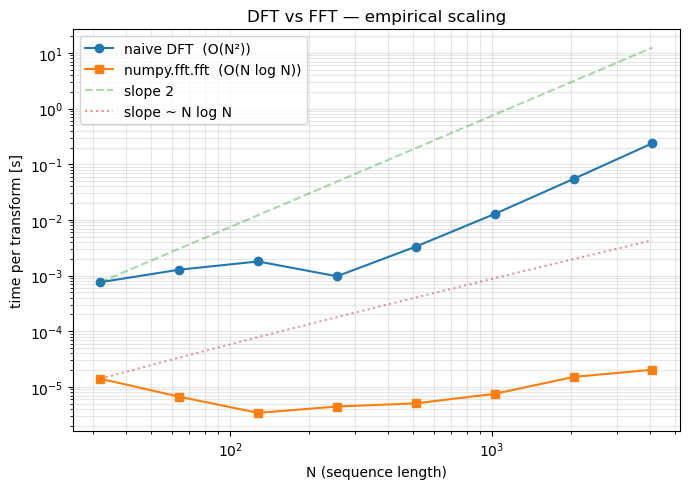

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(Ns, t_dft, 'o-', label='naive DFT  (O(N²))')
ax.loglog(Ns, t_fft, 's-', label='numpy.fft.fft  (O(N log N))')
# Reference slopes
N_arr = np.array(Ns, dtype=float)
ax.loglog(N_arr, t_dft[0] * (N_arr / Ns[0])**2, '--', alpha=0.4, label='slope 2')
ax.loglog(N_arr, t_fft[0] * (N_arr / Ns[0]) * np.log2(N_arr) / np.log2(Ns[0]), ':', alpha=0.5, label='slope ~ N log N')
ax.set_xlabel('N (sequence length)'); ax.set_ylabel('time per transform [s]')
ax.set_title('DFT vs FFT — empirical scaling')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

Cooley & Tukey (1965) reported a similar speed-up empirically; the difference at $N = 4096$ on a modern laptop is typically four to five orders of magnitude. This is the gap that made real-time spectral analysis possible — and, in 1965, made seismometer-based detection of underground nuclear tests feasible (Heideman, Johnson, & Burrus, 1984).

## 2. Spectral leakage

When the record length $T$ is not an integer multiple of the analysed period, the DFT smears the line spectrum across neighbouring bins (Oppenheim & Schafer, 2010, §10). Demonstrate the effect on a 12.5 Hz tone, with and without a Hann window, at two record lengths.

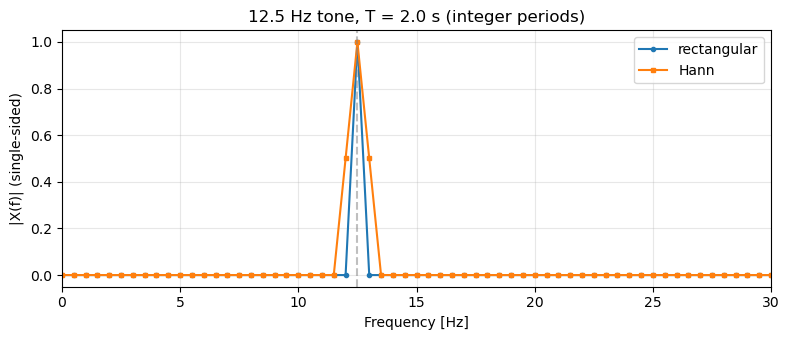

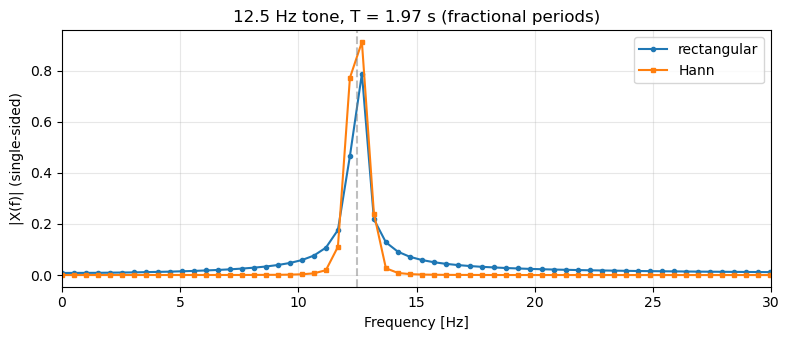

In [4]:
def amp_spectrum(x, fs, window=None):
    N = x.shape[0]
    if window is None:
        w   = np.ones(N); win_corr = N
    else:
        w   = window;     win_corr = w.sum()
    X = np.fft.rfft(x * w)
    A = 2.0 * np.abs(X) / win_corr
    f = np.fft.rfftfreq(N, d=1.0/fs)
    return f, A

fs   = 1000.0
f_t  = 12.5                  # tone frequency

# Two record lengths: one that fits an integer number of periods (no leakage)
# and one that does not (leakage).
T_fit = 2.0                  # seconds — 25 periods at 12.5 Hz, perfect
T_bad = 1.97                 # seconds — fractional periods, leakage expected

for T_len, label in [(T_fit, 'integer periods'), (T_bad, 'fractional periods')]:
    N = int(fs * T_len)
    t = np.arange(N) / fs
    x = np.cos(2*np.pi*f_t*t)

    f_rect, A_rect = amp_spectrum(x, fs)                          # rectangular
    f_hann, A_hann = amp_spectrum(x, fs, np.hanning(N))           # Hann

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(f_rect, A_rect, 'o-', ms=3, label='rectangular')
    ax.plot(f_hann, A_hann, 's-', ms=3, label='Hann')
    ax.axvline(f_t, color='gray', ls='--', alpha=0.5)
    ax.set_xlim(0, 30)
    ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('|X(f)| (single-sided)')
    ax.set_title(f'12.5 Hz tone, T = {T_len} s ({label})')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

**Reading the plots.**
- *Integer-periods, rectangular window:* a single bin at 12.5 Hz with the correct amplitude (= 1.0). Hann broadens the main lobe but suppresses sidelobes.
- *Fractional-periods, rectangular window:* energy from the 12.5 Hz tone leaks into adjacent bins — the spectrum decays only as $1/f$ away from the tone. The peak amplitude is also lower than 1.0 (scalloping loss).
- *Fractional-periods, Hann window:* the spectrum is much cleaner, at the cost of a wider main lobe and a slight amplitude shift. This is exactly why every Sinha-style HOS estimator in the simulation pipeline uses a Hann window by default (cf. `02_simula/sprints/01_hos_core.md`).

## 3. Wiener–Khinchin and Welch averaging

The Wiener–Khinchin theorem states that the PSD of a wide-sense-stationary process $X(t)$ is the Fourier transform of its autocorrelation $R_X(\tau)$ (Wiener, 1930; Khinchin, 1934). Equivalently, the squared FFT magnitude of a finite record is an *unbiased but high-variance* estimate of the PSD — the **periodogram**. Welch (1967) averages many short windowed periodograms to trade frequency resolution for variance reduction.

We verify this on a synthetic process: white Gaussian noise filtered by a 2nd-order Butterworth low-pass at 50 Hz.

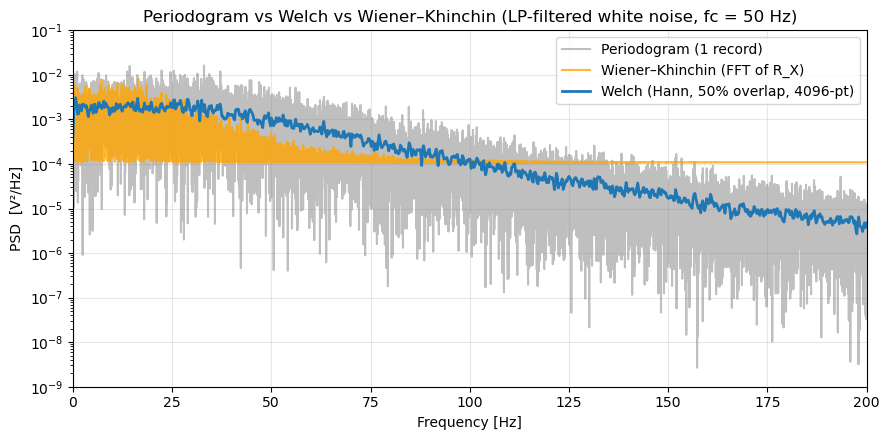

In [5]:
from scipy.signal import butter, lfilter

fs    = 1000.0
T_len = 60.0                       # seconds
N     = int(fs * T_len)

# White noise → Butterworth LP (cutoff 50 Hz)
noise = rng.standard_normal(N)
b, a  = butter(2, Wn=50.0/(fs/2.0))
x     = lfilter(b, a, noise)

# (a) Single-record periodogram (high variance)
X     = np.fft.rfft(x)
f_per = np.fft.rfftfreq(N, d=1.0/fs)
S_per = (np.abs(X)**2) / (fs * N)               # one-sided PSD, V²/Hz
S_per[1:-1] *= 2

# (b) Welch estimate (variance-reduced)
f_w, S_w = welch(x, fs=fs, nperseg=4096, noverlap=2048, window='hann')

# (c) Wiener–Khinchin direct: FFT of the biased autocorrelation
x_zm   = x - x.mean()
Rx_full = np.correlate(x_zm, x_zm, mode='full') / N        # biased autocorrelation
Rx     = Rx_full[N-1:]                                     # τ ≥ 0
S_wk   = 2.0 * np.real(np.fft.rfft(Rx)) / fs               # one-sided
f_wk   = np.fft.rfftfreq(2*len(Rx)-1, d=1.0/fs)[:len(S_wk)]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(f_per, S_per,           color='gray',  alpha=0.5, label='Periodogram (1 record)')
ax.semilogy(f_wk,  np.abs(S_wk),    color='orange', alpha=0.8, label='Wiener–Khinchin (FFT of R_X)')
ax.semilogy(f_w,   S_w,             color='C0',    lw=2,      label='Welch (Hann, 50% overlap, 4096-pt)')
ax.set_xlim(0, 200); ax.set_ylim(1e-9, 1e-1)
ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('PSD  [V²/Hz]')
ax.set_title('Periodogram vs Welch vs Wiener–Khinchin (LP-filtered white noise, fc = 50 Hz)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plots.**

- The grey periodogram has the right *expected* shape but huge variance — every realisation looks different.
- The orange curve is the FFT of the biased autocorrelation $\hat R_X(\tau)$; it tracks the periodogram closely (up to a factor of 2 from the one-sided convention), confirming Wiener–Khinchin numerically.
- The blue Welch estimate has dramatically lower variance and clearly shows the −40 dB/dec roll-off above the 50 Hz cut-off, exactly as predicted for a 2nd-order Butterworth low-pass.

## Take-aways

- The DFT is computable in $O(N^2)$ from first principles; the FFT factorisation reduces this to $O(N \log N)$, with empirical speed-ups of four to five orders of magnitude at $N = 4096$.
- Spectral leakage is a windowing artefact, not a numerical error. A Hann window is the standard mitigation; for HOS work the same window choice is what makes the Kim–Powers (1979) bicoherence normalisation valid — see `02_simula/sprints/01_hos_core.md`.
- Wiener–Khinchin holds *empirically* on a random-process realisation: the FFT of the autocorrelation matches the periodogram. Welch averaging is the operational tool that turns the noisy periodogram into a usable PSD estimate.